In [2]:
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as rt

import json, pickle
from go_ml.go_utils import godag, go2parents_isa, get_ancestors
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open('/home/andrew/GO_interp/data/proteinf_go_terms.json', 'r') as f:
    go_terms_pi = json.load(f)
with open('handpicked_dataset.pkl', 'rb') as f:
    go_domain_df, prot_dict = pickle.load(f)

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [3]:
with open('hp_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)

import torch
def logit_entropy(logit_l, base_ind, max_len=800):
    max_entr = np.log(len(base_ind))
    entropy_val = np.zeros((len(logit_l), max_len+1)) + max_entr
    for i, bert_logit in enumerate(logit_l):
        sl = bert_logit.shape[0]-2
        p = torch.softmax(bert_logit.cpu()[:, base_ind], dim=-1)
        res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)
        entropy_val[i, 1:sl+1] = res_entropy_imp[1:-1].numpy()
    return entropy_val

base_ind = list(range(4, 24))
entropy_eval_dict = {k:logit_entropy(ll, base_ind, max_len=800) for k, ll in logit_eval_dict.items()}

pid_entropy_dict = {}
for i, (pid, seq) in enumerate(prot_dict.items()):
    pid_entropy_dict[pid] = entropy_eval_dict['perc'][i]

In [4]:
from collections import Counter
AA_dict = Counter(''.join(prot_dict.values()).upper())
AA_val = list(AA_dict.keys())
AA_dict = {AA_val: i for i, AA_val in enumerate(AA_val)}

In [5]:
# import seaborn as sea
# import pandas as pd
# df_ind = 0
# seq_entry = go_domain_df.iloc[df_ind]
# pid, go_ind, domain_mask = tuple(seq_entry)
# go_term = go_terms[go_ind]

# si, fi = 3, 33
# seq = prot_dict[pid][si:fi].upper()
# seq_len = len(seq)
# seq_entropy = pid_entropy_dict[pid][si:fi]

# data = {"cat": seq, "val": seq_entropy}
# df = pd.DataFrame(data)

# fig, ax = plt.subplots(1, 1, figsize=(12, 4))
# # sea.lineplot(seq_entropy)
# sea.barplot(seq_entropy, ax=ax)
# ax.set_xticks(np.arange(seq_len), seq)
# ax.set_xlabel('Base Residue')
# ax.set_ylabel('Entropy Score')
# plt.show()

In [6]:
with open('hp_eval.pkl', 'rb') as f:
    esm_eval_dict = pickle.load(f)
with open('hp_eval_pi.pkl', 'rb') as f:
    pi_eval_dict = pickle.load(f)

In [92]:
df_ind = 18
seq_entry = go_domain_df.iloc[df_ind]
pid, go_ind, domain_mask = tuple(seq_entry)
go_term = go_terms[go_ind]
go_ind_pi = go_terms_pi.index(go_term)
print(seq_entry, go_term, godag[go_term])
ancestor_terms = get_ancestors(go_term, go2parents_isa)
ancestor_ind_pi = [go_terms_pi.index(at) for at in ancestor_terms if at in go_terms_pi]
ancestor_ind = [go_terms.index(at) for at in ancestor_terms if at in go_terms]


Accession                                                 Q9ESN2
GO ID                                                          1
Domain Mask    [False, False, False, False, False, False, Fal...
Name: 70, dtype: object GO:0005515 GO:0005515	level-02	depth-02	protein binding [molecular_function]


In [ ]:
esm_var_scores = (1/(1+np.exp(-esm_eval_dict[pid]))).var(axis=1)
pi_var_scores = pi_eval_dict[pid].var(axis=1)

In [90]:
def norm_seq(seq):
    return (seq-seq.min()) / (seq.max()-seq.min())

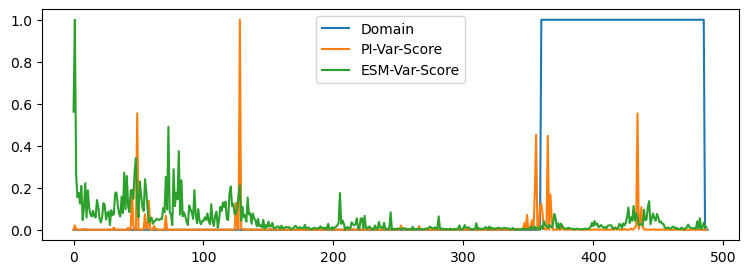

In [91]:
fig, ax = plt.subplots(1,1, figsize=(9,3))
ax.plot(norm_seq(domain_mask.astype(float)), label='Domain')

ax.plot(norm_seq(pi_var_scores[:, ancestor_ind_pi].sum(axis=1)), label='PI-Var-Score')
# ax.plot(norm_seq(pi_var_scores.sum(axis=1)), label='PI-Var-Score')

ax.plot(norm_seq(esm_var_scores[:, go_ind]), label='ESM-Var-Score')
# ax.plot(norm_seq(esm_var_scores[:, ancestor_ind].sum(axis=1)), label='ESM-Var-Score')
# ax.plot(norm_seq(pid_entropy_dict[pid][:len(prot_dict[pid])]), label='H-Score')
ax.legend()
fig.show()

In [ ]:
sess = rt.InferenceSession("/home/andrew/GO_interp/data/proteinf_model.onnx")

AMINO_ACID_VOCABULARY = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
RESIDUE_TO_INT = {aa: idx for idx, aa in enumerate(AMINO_ACID_VOCABULARY)}
import numpy as np
oh_mat = np.eye(len(RESIDUE_TO_INT), dtype=np.float32)
def get_onehot(seq_ind):
    seq_oh = oh_mat[seq_ind]
    return seq_oh

In [ ]:
from tqdm.notebook import tqdm
def token_pa(seq):
    seq_len = len(seq)
    seq_ind = np.array([RESIDUE_TO_INT[c] for c in seq]).reshape((1, -1))
    mut_ind = np.arange(20)
    eval_dict = {}
    base_batch_seq = np.tile(seq_ind, (mut_ind.shape[0], 1))
    base_batch_len = np.full(mut_ind.shape, seq_len, dtype=np.int32)
    for ri in tqdm(range(seq_len)):
        batch_seq = base_batch_seq.copy()
        batch_seq[:, ri] = mut_ind
        batch_seq_oh = get_onehot(batch_seq)
        logits = sess.run(output_names=['output'], input_feed={'sequence_length': base_batch_len, 'sequence': batch_seq_oh})
        eval_dict[ri] = logits
    eval_mat = np.concatenate([eval_dict[i] for i in range(0, len(eval_dict))])
    return eval_mat

  0%|          | 0/488 [00:00<?, ?it/s]

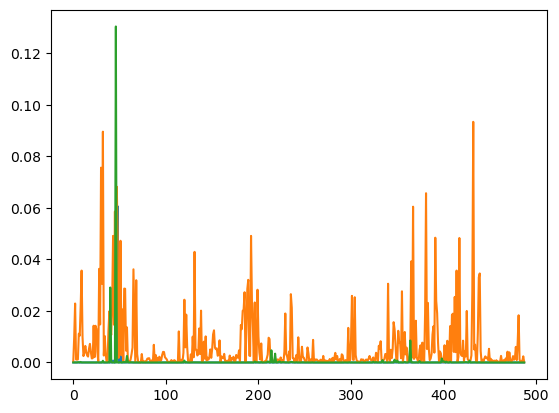

In [11]:
var_scores = eval_mat.var(axis=1)
vs = var_scores.sum(axis=-1)
nz_go_ind = list(set( (var_scores * (var_scores > 0.001)).nonzero()[1] ))
plt.plot(var_scores[:, nz_go_ind[::30]])
plt.show()

In [70]:
from go_ml.go_utils import godag, go2parents_isa, get_ancestors
ancestors = get_ancestors(go_term, go2parents_isa)
ancestor_ind = [go_terms_pi.index(a) for a in ancestors]

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


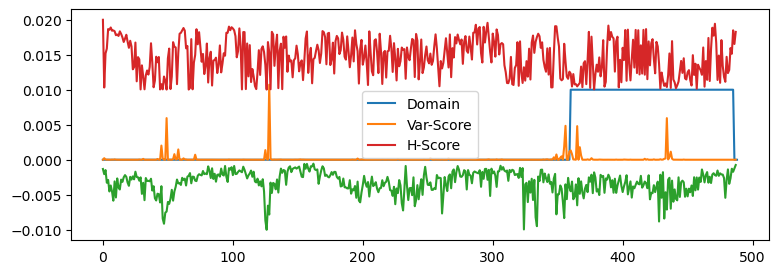

In [18]:
seq_entry = go_domain_df[go_domain_df['Accession'] == seq_id].iloc[0]
pid, go_ind, domain_mask = tuple(seq_entry)
go_term = go_terms[go_ind]
go_inf_ind = go_terms_pi.index(go_term)

vs_max = var_scores.max(axis=-1) /var_scores.max() * 1e-2

fig, ax = plt.subplots(1,1, figsize=(9,3))
ax.plot(domain_mask*1e-2, label='Domain')
ax.plot(var_scores[:, go_inf_ind], label='Var-Score')
# ax.plot(vs/vs.max()*1e-2, label='Var-Score')
ax.plot(-vs_max)
ax.plot(pid_entropy_dict[seq_id][:seq_len]/3*1e-2+1e-2, label='H-Score')
ax.legend()
fig.show()

In [13]:
with open('hp_logits.pkl', 'rb') as f:
   logit_eval_dict = pickle.load(f)

import torch
def logit_entropy(logit_l, base_ind, max_len=800):
    max_entr = np.log(len(base_ind))
    entropy_val = np.zeros((len(logit_l), max_len+1)) + max_entr
    for i, bert_logit in enumerate(logit_l):
        sl = bert_logit.shape[0]-2
        p = torch.softmax(bert_logit.cpu()[:, base_ind], dim=-1)
        res_entropy_imp = -(torch.log(p)*p).sum(dim=-1)
        entropy_val[i, 1:sl+1] = res_entropy_imp[1:-1].numpy()
    return entropy_val

base_ind = list(range(4, 24))
entropy_eval_dict = {k:logit_entropy(ll, base_ind, max_len=800) for k, ll in logit_eval_dict.items()}

pid_entropy_dict = {}
for i, (pid, seq) in enumerate(prot_dict.items()):
    pid_entropy_dict[pid] = entropy_eval_dict['perc'][i]

In [103]:
with open('hp_eval.pkl', 'rb') as f:
    eval_dict_esm = pickle.load(f)
eval_mat_esm = 1/ (1 + np.exp(-eval_dict_esm[seq_id]))

In [129]:
var_scores_esm = eval_mat_esm.var(axis=1)
vs_esm = var_scores_esm.sum(axis=1)

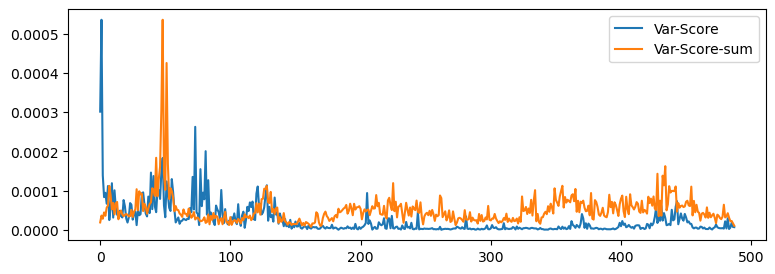

In [134]:
seq_entry = go_domain_df[go_domain_df['Accession'] == seq_id].iloc[0]
pid, go_ind, domain_mask = tuple(seq_entry)
go_term = go_terms[go_ind]
go_inf_ind = go_terms_pi.index(go_term)

fig, ax = plt.subplots(1,1, figsize=(9,3))
# ax.plot(domain_mask*1e-2, label='Domain')
ax.plot(var_scores_esm[:, go_ind], label='Var-Score')
ax.plot(vs/vs.max()*var_scores_esm[:, go_ind].max(), label='Var-Score-sum')

# ax.plot(var_scores[:, ancestor_ind], label='Var-Score')
ax.legend()
fig.show()

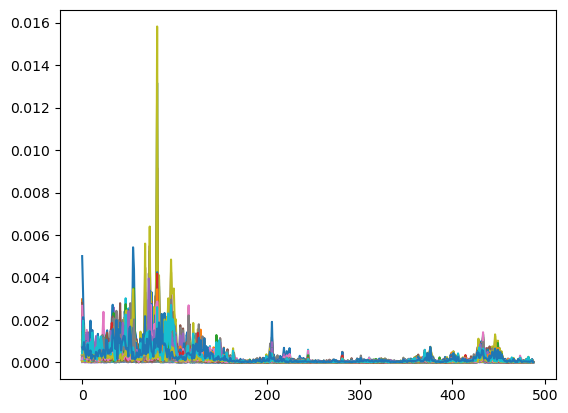

In [ ]:

nz_go_ind = list(set( (var_scores * (var_scores > 0.001)).nonzero()[1] ))
plt.plot(var_scores[:, nz_go_ind[:256]])
plt.show()